# AI510 Real Time Credit Card Fraud Detection Using AI on Cloud Platforms

This notebook is part of our AI510 team project. The goal is to build an AI based fraud detection system that can analyze credit card transactions, detect suspicious activity, and simulate real time fraud detection.

Main steps:
1. Load the Kaggle credit card fraud dataset
2. Perform exploratory data analysis
3. Train anomaly detection models
4. Evaluate model performance
5. Simulate real time transaction processing
6. Save prediction results for monitoring and reporting

In [2]:
!pip install imbalanced-learn

In [3]:
import pandas as pd

df = pd.read_csv("creditcard.csv")

print("Dataset shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())

df.head()

Dataset shape: (208035, 31)
Missing values: 16


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [4]:
!pip install kaggle

In [5]:
!pip install kagglehub

In [6]:
import kagglehub

path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset: /kaggle/input/creditcardfraud


In [7]:
import pandas as pd

df = pd.read_csv("/kaggle/input/creditcardfraud/creditcard.csv")

print("Dataset shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())

df.head()

Dataset shape: (284807, 31)
Missing values: 0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [8]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


In [9]:
df['Class'].value_counts(normalize=True)

,proportion
Class,
0,0.998273
1,0.001727


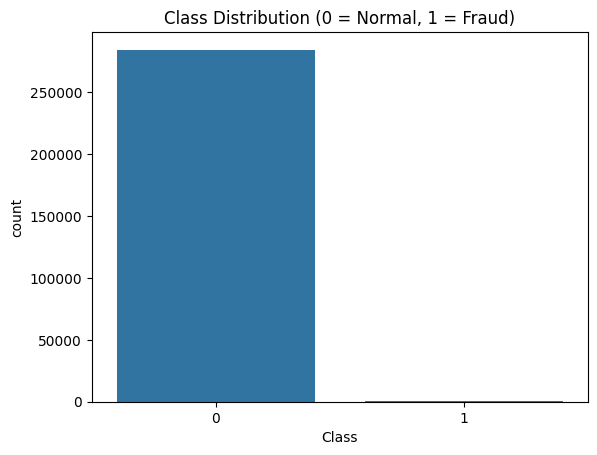

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Class', data=df)
plt.title("Class Distribution (0 = Normal, 1 = Fraud)")
plt.show()

In [11]:
X = df.drop('Class', axis=1)
y = df['Class']

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    n_estimators=100,
    contamination=0.002,
    random_state=42
)

model.fit(X_train)

IsolationForest(contamination=0.002, random_state=42)

In [16]:
y_pred = model.predict(X_test)

In [17]:
import numpy as np

In [18]:
y_pred = np.where(y_pred == -1, 1, 0)

In [19]:
from sklearn.metrics import classification_report

In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.32      0.36      0.34        98

    accuracy                           1.00     56962
   macro avg       0.66      0.68      0.67     56962
weighted avg       1.00      1.00      1.00     56962



In [21]:
from sklearn.metrics import roc_auc_score

In [22]:
auc = roc_auc_score(y_test, y_pred)
print("ROC AUC:", auc)

ROC AUC: 0.677911960366589


In [23]:
!pip install tensorflow

In [24]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

In [25]:
input_dim = X_train.shape[1]

In [26]:
input_layer = Input(shape=(input_dim,))

In [27]:
encoded = Dense(16, activation='relu')(input_layer)

In [28]:
decoded = Dense(input_dim, activation='linear')(encoded)

In [29]:
autoencoder = Model(inputs=input_layer, outputs=decoded)

In [30]:
autoencoder.compile(optimizer='adam', loss='mse')

In [31]:
autoencoder.fit(X_train, X_train, epochs=5, batch_size=256, shuffle=True)

Epoch 1/5
891/891 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.6597
Epoch 2/5
891/891 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.4413
Epoch 3/5
891/891 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4182
Epoch 4/5
891/891 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4150
Epoch 5/5
891/891 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4141


In [32]:
reconstructions = autoencoder.predict(X_test)

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


In [33]:
mse = np.mean(np.power(X_test - reconstructions, 2), axis=1)

In [34]:
threshold = np.percentile(mse, 99.8)

In [35]:
ae_pred = np.where(mse > threshold, 1, 0)

In [36]:
print(classification_report(y_test, ae_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.20      0.23      0.22        98

    accuracy                           1.00     56962
   macro avg       0.60      0.62      0.61     56962
weighted avg       1.00      1.00      1.00     56962



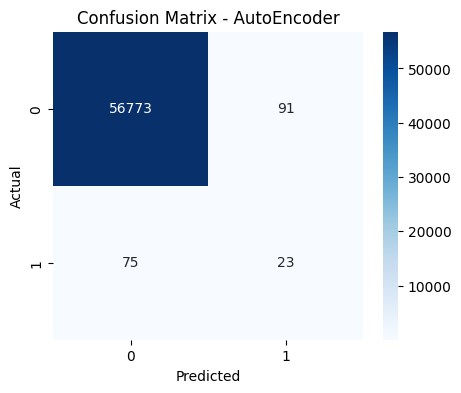

In [37]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, ae_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - AutoEncoder")
plt.show()

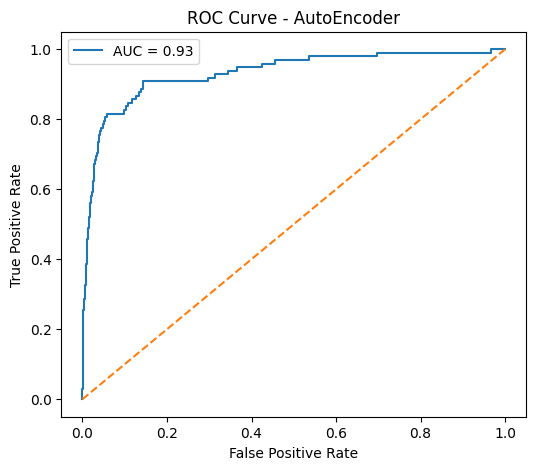

In [38]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, mse)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - AutoEncoder")
plt.legend()
plt.show()

In [39]:
# Create a small sample to simulate real-time transactions
simulation_data = df.sample(20, random_state=42)

simulation_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
43428,41505.0,-16.526507,8.584972,-18.649853,9.505594,-13.793819,-2.832404,-16.701694,7.517344,-8.507059,...,1.190739,-1.127670,-2.358579,0.673461,-1.413700,-0.462762,-2.018575,-1.042804,364.19,1
49906,44261.0,0.339812,-2.743745,-0.134070,-1.385729,-1.451413,1.015887,-0.524379,0.224060,0.899746,...,-0.213436,-0.942525,-0.526819,-1.156992,0.311211,-0.746647,0.040996,0.102038,520.12,0
29474,35484.0,1.399590,-0.590701,0.168619,-1.029950,-0.539806,0.040444,-0.712567,0.002299,-0.971747,...,0.102398,0.168269,-0.166639,-0.810250,0.505083,-0.232340,0.011409,0.004634,31.00,0
276481,167123.0,-0.432071,1.647895,-1.669361,-0.349504,0.785785,-0.630647,0.276990,0.586025,-0.484715,...,0.358932,0.873663,-0.178642,-0.017171,-0.207392,-0.157756,-0.237386,0.001934,1.50,0
278846,168473.0,2.014160,-0.137394,-1.015839,0.327269,-0.182179,-0.956571,0.043241,-0.160746,0.363241,...,-0.238644,-0.616400,0.347045,0.061561,-0.360196,0.174730,-0.078043,-0.070571,0.89,0


In [40]:
for i, row in simulation_data.iterrows():
    transaction = row.drop('Class').values.reshape(1, -1)

    # scale input
    transaction = scaler.transform(transaction)

    # reconstruction
    reconstruction = autoencoder.predict(transaction)

    # compute error
    error = np.mean((transaction - reconstruction) ** 2)

    # prediction
    prediction = 1 if error > threshold else 0

    print(f"Transaction {i} -> Predicted: {prediction}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
Transaction 43428 -> Predicted: 1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
Transaction 49906 -> Predicted: 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Transaction 68279 -> Predicted: 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Transaction 267585 -> Predicted: 0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Transaction 26525 -> Predicted: 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
Transaction 74422 -> Predicted: 0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [41]:
for i, row in simulation_data.iterrows():
    transaction = row.drop('Class').values.reshape(1, -1)
    actual = int(row['Class'])

    transaction = scaler.transform(transaction)

    reconstruction = autoencoder.predict(transaction)

    error = np.mean((transaction - reconstruction) ** 2)

    prediction = 1 if error > threshold else 0

    print(f"Transaction {i} -> Actual: {actual} | Predicted: {prediction}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Transaction 43428 -> Actual: 1 | Predicted: 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Transaction 49906 -> Actual: 0 | Predicted: 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Transaction 29474 -> Actual: 0 | Predicted: 0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Transaction 276481 -> Actual: 0 | Predicted: 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Transaction 278846 -> Actual: 0 | Predicted: 0


...

Transaction 68279 -> Actual: 0 | Predicted: 0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
Transaction 267585 -> Actual: 0 | Predicted: 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Transaction 26525 -> Actual: 0 | Predicted: 0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Transaction 74422 -> Actual: 0 | Predicted: 0


In [42]:
simulation_results = []

for i, row in simulation_data.iterrows():
    transaction = row.drop('Class').values.reshape(1, -1)
    actual = int(row['Class'])

    transaction = scaler.transform(transaction)
    reconstruction = autoencoder.predict(transaction, verbose=0)
    error = np.mean((transaction - reconstruction) ** 2)
    prediction = 1 if error > threshold else 0

    simulation_results.append({
        "Transaction_ID": i,
        "Actual_Class": actual,
        "Predicted_Class": prediction,
        "Reconstruction_Error": error
    })

simulation_results_df = pd.DataFrame(simulation_results)
simulation_results_df

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

,Transaction_ID,Actual_Class,Predicted_Class,Reconstruction_Error
0,43428,1,1,23.064762
1,49906,0,0,0.549786
2,29474,0,0,0.223317
3,276481,0,0,0.151468
4,278846,0,0,0.093292
5,101565,0,0,0.606189
6,260880,0,0,0.126044
7,214337,0,0,0.354373
8,201575,0,0,0.201062
9,81055,0,0,1.664973


In [43]:
simulation_results_df.to_csv("simulation_results.csv", index=False)

In [44]:
from google.colab import files
files.download("simulation_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [45]:
from sklearn.metrics import precision_score, recall_score, f1_score

threshold_results = []

for percentile in [99.0, 99.2, 99.4, 99.6, 99.8]:
    current_threshold = np.percentile(mse, percentile)
    current_pred = np.where(mse > current_threshold, 1, 0)

    threshold_results.append({
        "Threshold_Percentile": percentile,
        "Threshold_Value": current_threshold,
        "Precision": precision_score(y_test, current_pred),
        "Recall": recall_score(y_test, current_pred),
        "F1_Score": f1_score(y_test, current_pred)
    })

threshold_results_df = pd.DataFrame(threshold_results)
threshold_results_df

,Threshold_Percentile,Threshold_Value,Precision,Recall,F1_Score
0,99.0,3.586568,0.064912,0.377551,0.110778
1,99.2,4.200005,0.074561,0.346939,0.122744
2,99.4,5.232282,0.081871,0.285714,0.127273
3,99.6,6.726582,0.114035,0.265306,0.159509
4,99.8,10.205476,0.201754,0.234694,0.216981


In [46]:
threshold = np.percentile(mse, 99.8)
ae_pred = np.where(mse > threshold, 1, 0)

In [47]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

final_comparison = pd.DataFrame({
    "Model": ["Isolation Forest", "AutoEncoder"],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, ae_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, ae_pred)
    ],
    "F1_Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, ae_pred)
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, y_pred),
        roc_auc
    ]
})

final_comparison

,Model,Precision,Recall,F1_Score,ROC_AUC
0,Isolation Forest,0.318182,0.357143,0.336538,0.677912
1,AutoEncoder,0.201754,0.234694,0.216981,0.931530
